## Homework 02: Statistical Foundations 

#### Due Date: Sunday, September 13th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 603 Syllabus. 


### Introduction

This homework explores several of the statistical ideas introduced in Week 2 through small computational experiments.

You will work with:

- **descriptive statistics and visualizations** to examine the shape of a distribution and the effect of outliers;
- **repeated random sampling** to study sampling distributions, the Central Limit Theorem, and the effect of sample size;
- **scatterplots and correlation** to examine relationships between variables, the effect of random noise, and differences among groups.

The goal is not to test advanced Python programming. You should use the Week 2 Coding Notebook and the appendices in this homework as references. In several places, you are also explicitly encouraged to use an AI assistant to help generate or modify code that uses Python features you may not yet have learned.

When you use AI-generated code, however, you are expected to understand the basic purpose of the code and to be able to identify the parts that control the quantities being studied.

Problems 1–3 contain the computational activities. Problem 4 asks multiple-choice questions about what you observed, and Problem 5 asks you to reflect on the broader lessons from the experiments.

### Grading

- All homeworks in DX 603 are worth **80 points**.
- This homework has **5 problems, each worth 16 points**.
- Multi-part problems will have approximately equal points for each subpart. Check Gradescope for precise point values. 
- Problem 5 is the reflection question and will be graded after the submission deadline.

For the first two homeworks, the autograder will report results immediately after submission for the automatically graded portions, and you may resubmit as many times as you like up to the deadline.

The reflection question will be AI graded after the deadline. We use a human-in-the-loop approach: any deductions from the AI grading will be reviewed by a Learning Facilitator or instructor.

You may submit a regrade request on Gradescope after your grades are released. The instructor will review the request and make any appropriate adjustment.

In [1]:
# Useful imports and utilities

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as mtick

import random
import statistics
import math

random_seed = 42

# Problem 1: Describing a Distribution and Exploring Outliers

We will use the same dataset as in Homework 1. 

In [2]:
# Since you only need to do this once, uncomment the following line, run the cell, and then recomment or delete this cell.
# Or do this the usual way you do installs (e.g., in Terminal on a Mac). 

# !pip install kagglehub

import kagglehub

# Download the dataset to the local Kaggle cache
salary_dataset_path = kagglehub.dataset_download(
    "abhishek14398/salary-dataset-simple-linear-regression"
)

salary_dataset_path_to_file = os.path.join(
    salary_dataset_path,
    "Salary_dataset.csv"
)

salary_data_raw = pd.read_csv(salary_dataset_path_to_file)

### Part A

We will explore some of the basic statistical functions in Pandas; refer to the Appendix as needed. 

**To Do:** Create a Series `salary` from the `Salary` column in `salary_data_raw`

In [3]:
# Your code here



**To Do:** Write an expression that returns the `shape` (should be `(30,)`)

In [4]:
# Your code here



**To Do:** Write an expression that returns the minimum salary and its index as a pair (minimum salary,index)

In [5]:
# Your code here



**To Do:** Write an expression that returns the maximum salary and its index as a pair (maximum salary,index)

In [6]:
# Your code here



**To Do:** Write an expression that returns the range of the salary data and assign it to  a variable `rng`.

In [7]:
rng = 0      # replace with your answer
rng

0

**To Do:** Write a Boolean expression which is True if there are any duplicate salaries in the data and assign it to `dups`.

(Hint: You can find the length of a Series using the usual Python `len(...)` function. There is also a useful Series method in the Appendix for counting unique values.)

In [8]:
dups = 0      # replace with your answer
dups

0

**To Do:** Write an expression that calculates the **proportion of salaries within one standard deviation of the mean**, and assign the result to `pro_std1`.

**Hint:** Comparisons such as `salary >= value` produce a Series of Boolean values. Since `True` is treated as 1 and `False` as 0, the **mean** of a Boolean Series gives the proportion of values for which the condition is true.

In [9]:
pro_std1 = 0      # replace with your answer
pro_std1

0

### 1.A Graded Answer

If you have followed the directions above, there is nothing else to do here. Make sure you run the cell that prints out the answer!

In [10]:
# Your answer here, NOT in the next cell

a1a = (rng,dups,pro_std1)  # You shouldn't have to change this.

In [11]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1a = {a1a}')

a1a = (0, 0, 0)


### Part B

**To Do:** Display a one-dimensional scatter plot of the salary data (without jitter). Be sure to include an appropriate title and X-axis label. 

Hint: See the Coding Notebook for Week 2.

In [12]:
# Your code here



**To Do:** Display a one-dimensional scatter plot of the salary data WITH jitter.  Be sure to include an appropriate title and X-axis label. 

In [13]:
# Your code here


**To Do:** Display a Histogram of the Salary Data.

Experiment with several choices for the number of bins. Choose a value that gives a useful view of the shape of the distribution.

Hint: You may use the simple one-line Pandas histogram command. If you would like to add an appropriate title and x-axis label, you may ask an AI assistant to help you modify the plotting code.

In [14]:
# Your code here


**To Do:** Display a Kernel-Density Estimate Plot of the Salary data.  Be sure to include an appropriate title and X-axis label. 

**Hint:** Use the Pandas function `.plot.kde()`. 

In [15]:
# Your code here


**To Do:** Display a Box Plot of the Salary data.  Be sure to include an appropriate title and X-axis label. 

In [16]:
# Your code here


### 1.B Graded Answer

Calculate the first quartile $Q_1$, the median $Q_2$, the third quartile $Q_3$, and the interquartile range

$$
IQR = Q_3 - Q_1
$$

and assign these values as a tuple to `a1b`:

```python
a1b = (q1, q2, q3, iqr)
```

In [17]:
# Your answer here, NOT in the next cell

q1  = 0               # Replace the 0s with appropriate expressions
q2  = 0
q3  = 0
iqr = 0

a1b = (q1, q2, q3, iqr)     

In [18]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1b = {a1b}')

a1b = (0, 0, 0, 0)


### Part C

We will replace the highest salary with an **extreme value** to observe the effect of an outlier on the statistics. 

In [19]:
salary_extreme = salary.copy()

salary_extreme.loc[salary_extreme.idxmax()] = 500000

salary_extreme.tail()

25    105583.0
26    116970.0
27    112636.0
28    500000.0
29    121873.0
Name: Salary, dtype: float64

**To Do:**  Replot this data as a histogram. Again, adjust the number of bins as needed. 

In [20]:
# Your code here


**To Do:**  Replot this data as a Box Plot. 

In [21]:
# Your code here


### 1.C Graded Answer

Calculate the **change** in each of the following quantities after replacing the maximum salary with the extreme value:

- mean
- median
- standard deviation
- interquartile range (IQR)

For each quantity, calculate

$$
\text{change} = \text{modified value} - \text{original value}
$$

and assign the four changes as a tuple to `a1c` in the order

```python
a1c = (change_mean, change_std, change_iqr, change_median)
```

In [22]:
# Your answer here, NOT in the next cell

change_mean   = 0                   # Replace the 0s with appropriate expressions
change_std    = 0
change_median = 0
change_iqr    = 0

a1c = (
    change_mean,
    change_std,
    change_median,
    change_iqr
)

In [23]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1c = {a1c}')

a1c = (0, 0, 0, 0)


### Part D

**To Do:** Using the quartiles and IQR you calculated above, calculate the upper outlier cutoff for salary using the standard $1.5\times IQR$ rule. Recall that values greater than this cutoff are considered upper outliers.


In [24]:
upper_outlier_cutoff = ...          # Replace ... with your answer  

**To Do:** Using the cutoff value just calculated, determine the smallest whole-dollar salary that would be considered an outlier if we replaced the maximum salary with this salary, as in Part C. 

In [25]:
# Your code here

smallest_outlier_salary = ...            # Replace ... with your answer 
smallest_outlier_salary

Ellipsis

**To Do:** Convince yourself of the correctness of this by generating two boxplots:

- One where you have replaced the maximum salary with `smallest_outlier_salary`; and
- One where you have replaced the maximum salary with `smallest_outlier_salary - 1`.

You should see the first displayed as an outlier and the second not. 

In [26]:
# Your code here


### 1.D Graded Answer

Using the cutoff value just calculated, determine the smallest whole-dollar salary that would be considered an outlier if we replaced the maximum salary with this salary, as in Part C. 

Assign `a1d` to the smallest-outlier salary just determined. Make sure it is an integer!

In [27]:
# Your answer here, NOT in the next cell

a1d = 0

In [28]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1d = ${a1d:,}')

a1d = $0


# Problem 2: Repeated Sampling and Sampling Distributions

In [29]:
rng = np.random.default_rng(random_seed)

population = list(rng.exponential(scale=10, size=100000))

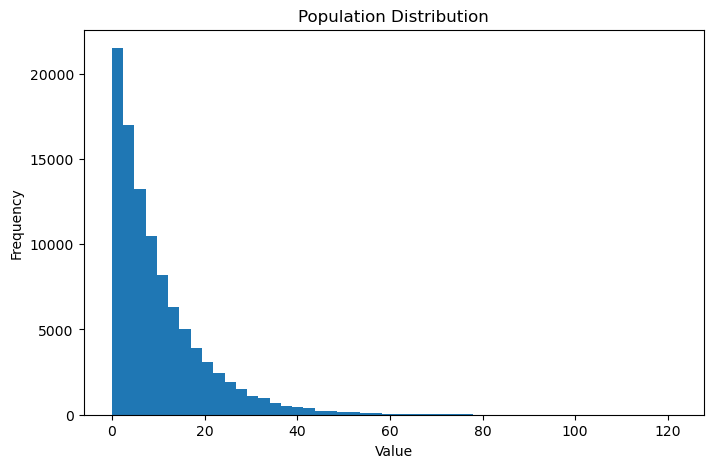

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(population, bins=50)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Population Distribution")
plt.show()

**To Do:** We want to simulate repeated sampling from the population.

> Generate 1,000 random samples of size 5 from population. For each sample, calculate its mean and store the 1,000 sample means in a variable called sample_means_5. Use `random.seed(random_seed)` to ensure reproducibility. 

Make sure you can identify:

- where the sample size is specified;
- where the number of repeated samples is specified; and
- where the mean of each sample is calculated.


You may use an AI assistant to help you write this code. Here is an example prompt for this problem:

> I have a Python list called population. Write simple Python code that:
> 
> - generates 1,000 random samples from population;
> - uses a sample size of 5;
> - calculates the mean of each sample using Python's statistics library; and
> - stores the 1,000 sample means in a Python list called sample_means_5.
> - Uses `random.seed(random_seed)` to ensure reproducibility. 
> 
> Please use basic Python lists and a for loop. Do not use NumPy arrays, Pandas, or list comprehensions.
> Keep the code simple enough for a student who has had about two weeks of introductory Python.

In [31]:
# Your code here



**To Do:** Create a histogram of the 1,000 sample means using 30 bins. Set the x-axis limits to 0 through 50 so that you can compare this distribution with the population distribution above. Add an appropriate title and axis labels.

Hint: Use `plt.xlim(0, 50)` to set the x-axis limits.  

In [34]:
# Your code here


**To Do:**  Now do the same experiment for a sample size of 100, producing a list `sample_means_100` and an appropriate histogram. 


In [35]:
# Your code here



**To Do:** Using your results above, calculate the following:

1. The mean of:
   - the population;
   - the 1,000 sample means for $n=5$;
   - the 1,000 sample means for $n=100$.

2. The standard deviation of:
   - the population;
   - the 1,000 sample means for $n=5$;
   - the 1,000 sample means for $n=100$.

3. For $n=5$ and $n=100$, calculate the predicted standard deviation of the sample means using

$$
\frac{\sigma}{\sqrt{n}},
$$

where $\sigma$ is the population standard deviation.


Hint: We have imported the `statistics` library in the first code cell above. Consult the documentation to
find the appropriate functions to apply to the list `population`. For the population standard deviation, use `pstdev`; 
for the sample standard deviation, use `stdev`. 


In [36]:
# Your code here


### Problem 2 Graded Answers

Assign `a2a` to a tuple containing, in this order:

1. population mean
2. mean of the sample means for $n=5$
3. mean of the sample means for $n=100$

In [37]:
## Your answer here, NOT in the next cell

a2a = (0,0,0)  # Replace with your answer

In [38]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2a = {a2a}')

a2a = (0, 0, 0)


Assign `a2b` to a tuple containing, in this order:

1. population standard deviation
2. observed standard deviation of the sample means for $n=5$
3. predicted standard deviation for $n=5$
4. observed standard deviation of the sample means for $n=100$
5. predicted standard deviation for $n=100$

In [39]:
## Your answer here, NOT in the next cell

a2b = (0,0,0,0,0)  # Replace with your answer

In [40]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2b = {a2b}')

a2b = (0, 0, 0, 0, 0)


**Note:** Compare the observed standard deviations of the sample means with the theoretical values $\sigma/\sqrt{n}$. Also notice how the shape of the sampling distribution becomes more nearly normal as the sample size increases.

# Problem 3: Relationships, Correlation, and Noise

So far, we have mostly examined individual variables and the behavior of repeated samples. We now turn to a different statistical question:

> **How are two variables related?**

For this problem, we will use data from the **Palmer Penguins** dataset, which contains measurements of several hundred penguins from three different species.

The dataset contains both **numerical** variables:

- `bill_length_mm`
- `bill_depth_mm`
- `flipper_length_mm`
- `body_mass_g`

and **categorical** variables:

- `species`
- `island`
- `sex`

We will focus initially on two numerical variables:

- `flipper_length_mm`: flipper length in millimeters
- `body_mass_g`: body mass in grams

A useful first step when examining the relationship between two numerical variables is to make a **scatterplot**. We can then summarize the strength and direction of a linear relationship using the **correlation coefficient**.

Recall that the correlation coefficient, usually written as $r$, ranges from $-1$ to $1$:

- $r$ close to $1$ indicates a strong positive linear relationship;
- $r$ close to $-1$ indicates a strong negative linear relationship;
- $r$ close to $0$ indicates little or no linear relationship.

In this problem, we will also investigate what happens to a relationship when we add **random noise** to the data.

In [41]:
# Load the Palmer Penguins data
url = (
    "https://raw.githubusercontent.com/allisonhorst/"
    "palmerpenguins/main/inst/extdata/penguins.csv"
)

penguins = pd.read_csv(url)

# Fix some problems with missing data (we'll do more on this next week)
penguins = penguins.dropna(subset=["flipper_length_mm", "body_mass_g"])

penguins["sex"] = penguins["sex"].fillna("Unknown")

penguins.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                342 non-null    object 
 7   year               342 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 24.0+ KB


## Part (i): Examine the Data

We can now examine the first few rows of the dataset and then summary statistics for the numerical variables.

In [42]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [43]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029240
std,5.459584,1.974793,14.061714,801.954536,0.817168
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


## Part (ii): Visualize the Relationship

We will begin by examining the relationship between:

- `flipper_length_mm`
- `body_mass_g`

**To Do:** Create a scatterplot with:

- **flipper length** on the horizontal axis;
- **body mass** on the vertical axis;
- appropriate axis labels;
- an informative title.

You may adapt code from this week's Coding Notebook or use an appropriate AI tool to help. 

In [44]:
# Create your scatterplot here



Look carefully at the scatterplot.

Consider:

- Is the relationship positive or negative?
- Does it appear weak, moderate, or strong?
- Is the relationship reasonably linear?
- Is there substantial variation around the overall pattern?

A scatterplot often tells us considerably more than a single numerical summary.

## Part (iii): Measure the Relationship

We can summarize the linear relationship between two numerical variables using the **correlation coefficient**.

Pandas provides the `.corr()` method for calculating correlation.

Calculate the correlation between `flipper_length_mm` and `body_mass_g`.

In [45]:
# Your code here


Compare the correlation coefficient with what you observed in the scatterplot.

The **sign** of the correlation tells us the direction of the relationship, while its **magnitude** tells us how strongly the two variables are linearly related.

## Part (iv): What Happens When We Add Noise?

Real-world measurements are rarely perfectly predictable. Many factors that we do not observe can affect a variable, and measurements themselves may contain random variation.

To explore this idea, we will generate one random value for each penguin and add it to that penguin's original `body_mass_g` value. This is similar to the way we added random jitter in the coding notebook, but here we will use a much larger amount of random variation so that we can see its effect on the relationship between the variables.

You may use an AI assistant to help you adapt the jitter code from the coding notebook.

**To Do:** Create a new column in `penguins` called `body_mass_noisy` by adding normally distributed random noise to `body_mass_g`.

Use:

- a mean of `0` for the random noise;
- a standard deviation of `750`;
- the random seed `random_seed`; and
- one random noise value for each row in `penguins`.

Here is an example prompt you could give an AI assistant:

> I have a Pandas DataFrame called `penguins` with a column called `body_mass_g`. In an earlier exercise, I used NumPy code of the form `x = x + rng.normal(...)` to add random jitter to data. Write similar simple Python code that creates a new column called `body_mass_noisy` by adding normally distributed random noise to `body_mass_g`. Use mean 0, standard deviation 750, and the random seed stored in `random_seed`. Generate one random value for each row in `penguins`.

After generating the code, be sure you can identify:

- where the random seed is specified;
- where the mean of the added noise is specified;
- where the standard deviation of the added noise is specified; and
- where the random noise is added to the original `body_mass_g` values.

In [75]:
# Your code here


**To Do:** Now create another scatterplot using:

- `flipper_length_mm` on the horizontal axis;
- `body_mass_noisy` on the vertical axis.

You may again use an AI assistant to help you modify your previous plotting code.

In [47]:
# Your code here


## Part (v): How Does Noise Affect Correlation?

**To Do:** Calculate the correlation between `flipper_length_mm` and `body_mass_noisy`.

Compare this correlation with the correlation you calculated earlier using the original `body_mass_g` values.

Then compare the two scatterplots.

In [48]:
# Calculate the correlation using the noisy body-mass measurements



Notice what happens when random noise is added:

* the positive relationship between flipper length and body mass is still visible;
* the points are more spread out around the general trend; and
* the correlation is weaker.

This illustrates an important idea: **random noise can make an existing relationship harder to detect and reduce the observed correlation.**

## Part (vi): Looking More Closely at the Data

There is one more important feature of this dataset that we have not yet used: the penguins belong to **three different species**.

So far, we have looked at the relationship between flipper length and body mass using all of the penguins together. A single scatterplot and a single correlation coefficient summarize the overall relationship, but they may hide differences among groups within the data.

**To Do:** Create another scatterplot of the **original** `flipper_length_mm` and `body_mass_g` measurements, but this time use a different color for each species.

You are encouraged to ask an AI tool for help. For example:

> I have a Pandas DataFrame called `penguins` containing `flipper_length_mm`, `body_mass_g`, and `species`. Write Python code to create a scatterplot of flipper length versus body mass, using a different color for each species. Include a legend, axis labels, and a title. You may use Matplotlib, Seaborn, or another standard Python plotting library.



In [49]:
# Create a scatterplot colored by species



Compare this graph with the first scatterplot.

Consider:

- Does knowing the species help explain some of the structure in the data?
- Do the three species occupy similar or different regions of the graph?
- Does the overall correlation tell the entire story?

This illustrates an important limitation of correlation:

> **A single correlation coefficient summarizes the relationship between two variables, but it does not necessarily reveal all of the structure present in the data.**

For that reason, statistical analysis usually combines numerical summaries with visualization and knowledge about the variables being studied.

## Part (vii): Correlation Within Each Species

The colored scatterplot suggests that the relationship between flipper length and body mass may differ within the three species.

**To Do:** Calculate the correlation between `flipper_length_mm` and `body_mass_g` separately for Adelie, Chinstrap, and Gentoo penguins.

Hint: To extract just the `Adelie` species, use this:

    adelie = penguins[penguins["species"] == "Adelie"]

You may use an AI assistant to help you write the code.

In [50]:
# Your code here

adelie_corr = 0.0              # Replace with your answers
chinstrap_corr = 0.0
gentoo_corr = 0.0

# Just to view the results
(adelie_corr,chinstrap_corr,gentoo_corr)       

(0.0, 0.0, 0.0)

### Problem 3 Graded Answers

#### 3.A Original Correlation

Calculate the correlation between `flipper_length_mm` and the original
`body_mass_g`.

Assign the result to `a3a`.

In [51]:
# Your answers here, NOT in the next cell

a3a = 0                 # Replace with your answer

In [52]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3a = {a3a}')

a3a = 0


#### 3.B Correlation After Adding Noise

Calculate the correlation between `flipper_length_mm` and
`body_mass_noisy`.

Assign the result to `a3b`.

In [53]:
# Your answers here, NOT in the next cell

a3b = 0                # Replace with your answer

In [54]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3b = {a3b}')

a3b = 0


#### 3.C Correlation Within Species

Assign `a3c` to a tuple containing the three correlations in this order:

1. Adelie
2. Chinstrap
3. Gentoo


In [55]:
# You shouldn't have to change this

a3c = (adelie_corr,chinstrap_corr,gentoo_corr)                      

In [56]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3c = {a3c}')

a3c = (0.0, 0.0, 0.0)


**Summary:** The overall correlation between flipper length and body mass is strong, but part of that relationship comes from differences among the three species. When we calculate correlations within each species separately, the relationships are weaker. This shows that a single overall correlation can partly reflect differences between groups, not just the relationship within each group.

## Problem 4: Multiple-Choice Concept Questions

Answer each of the following multiple-choice questions by setting the corresponding answer variable to the **number of the best answer**.

### 4.A — Why Were Median and IQR Less Affected?

In Problem 1, after replacing the largest salary with an extremely large value, the **median and IQR changed much less than the mean and standard deviation**.

Why?

1. The median and IQR depend mainly on the positions of values in the ordered data, so a single extreme value has relatively little effect on them.
2. The median and IQR ignore the largest 25% of all observations.
3. The mean and standard deviation are always larger than the median and IQR.
4. The median and IQR can only change when the sample size changes.

In [57]:
# Your answer here, NOT in the next cell

a4a = 0                       # Replace with your answer

In [58]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4a = {a4a}')

a4a = 0


### 4.B — What Does a Boxplot Whisker Mean?

In Problem 1, you found the upper outlier cutoff using

$$
Q_3 + 1.5\,IQR.
$$

You then saw that changing the largest salary by only one dollar could cause the upper whisker to move substantially.

What does the end of the upper whisker represent?

1. Exactly $Q_3 + 1.5\,IQR$
2. The value one standard deviation above the mean
3. The largest observed value that is not classified as an outlier
4. The maximum observed value, whether or not it is an outlier 

In [59]:
# Your answer here, NOT in the next cell

a4b = 0                       # Replace with your answer

In [60]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4b = {a4b}')

a4b = 0


### 4.C — Increasing the Sample Size

In Problem 2, you generated 1,000 sample means using samples of size $n=5$, then repeated the experiment using $n=100$.

Which statement best describes what happened when the sample size increased?

1. The sample means became more variable and more skewed.
2. The mean of the sampling distribution became much larger than the population mean.
3. The standard deviation of the sample means remained approximately equal to the population standard deviation.
4. The sample means remained centered near the population mean, but their distribution became narrower and more nearly normal.

In [61]:
# Your answer here, NOT in the next cell

a4c = 0                       # Replace with your answer

In [62]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4c = {a4c}')

a4c = 0


### 4.D — Predicting the Variability of Sample Means

In Problem 2, the population standard deviation was approximately $10$.

Approximately what standard deviation would you predict for the distribution of sample means when $n=100$?

1. $0.1$
2. $1$
3. $10$
4. $100$

In [63]:
# Your answer here, NOT in the next cell

a4d = 0                       # Replace with your answer

In [64]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4d = {a4d}')

a4d = 0


### 4.E — What Did Adding Noise Do?

In Problem 3, random noise was added to `body_mass_g`, and you then recalculated the correlation with flipper length.

What happened?

1. The correlation became stronger because the dataset contained more variation.
2. The relationship disappeared completely.
3. The scatterplot became more dispersed and the observed correlation became weaker.
4. The correlation stayed the same because the added noise had mean 0.

In [65]:
# Your answer here, NOT in the next cell

a4e = 0                       # Replace with your answer

In [66]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4e = {a4e}')

a4e = 0


### 4.F — Correlation and Hidden Group Structure

In Problem 3, the overall correlation between flipper length and body mass was stronger than the correlations calculated separately within the three penguin species.

What is the best interpretation?

1. The within-species correlations must have been calculated incorrectly.
2. Differences among the species contribute to the strong relationship observed when all penguins are analyzed together.
3. Flipper length and body mass are unrelated within each species.
4. A strong overall correlation proves that greater flipper length causes greater body mass.

In [67]:
# Your answer here, NOT in the next cell

a4f = 0                       # Replace with your answer

In [68]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4f = {a4f}')

a4f = 0


### 4.G — Choosing the Number of Histogram Bins

In Problem 1, you experimented with different numbers of bins when plotting the salary distribution.

Why can the choice of the number of bins matter?

1. Changing the number of bins changes the actual salary values in the dataset.
2. Too few bins can hide important features of the distribution, while too many bins can make the histogram look unnecessarily irregular.
3. The number of bins determines the mean and standard deviation.
4. A histogram is only valid if every bin contains the same number of observations.

In [69]:
# Your answer here, NOT in the next cell

a4g = 0                       # Replace with your answer

In [70]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4g = {a4g}')

a4g = 0


### 4.H — A Skewed Population and the Central Limit Theorem

In Problem 2, the original population was strongly right-skewed, but the distribution of sample means for $n=100$ was approximately normal.

What best explains this result?

1. Taking the mean changes every individual observation into a normally distributed value.
2. A sufficiently large random sample from any population must itself have a normal distribution.
3. The Central Limit Theorem says that, under appropriate conditions, the distribution of sample means becomes approximately normal as the sample size increases, even when the population itself is not normal.
4. The population became normal because 1,000 samples were generated.

In [71]:
# Your answer here, NOT in the next cell

a4h = 0                       # Replace with your answer

In [72]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4h = {a4h}')

a4h = 0


## Problem 5: Reflection

In Problems 1–3, you used several different ways to summarize and visualize data, including numerical statistics, histograms, boxplots, sampling distributions, scatterplots, and correlations.

**Reflection:** Explain why relying on only **one numerical summary or one visualization** can sometimes be misleading.

Your response should:

* be about **4–6 sentences**;
* refer to **at least two specific activities** from Problems 1–3;
* explain what each activity showed that would not have been as clear from another summary or visualization alone; and
* end with one broader lesson about why examining data in multiple ways can improve interpretation.



In [73]:
# Your answer here, NOT in the next cell

a5 = """
Write your reflection here.
"""

In [74]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print("a5 =")
print(a5)

a5 =

Write your reflection here.



## Appendix 1: Useful Pandas Series Methods

You are **not expected to memorize all Pandas commands**. When you know what kind of operation you want to perform, use this table or the Pandas documentation to find an appropriate method.

Assume that `x` is a Pandas Series.

| Method or expression | Purpose |
|---|---|
| `x.head()` | Display the first few values |
| `x.tail()` | Display the last few values |
| `x.min()` | Return the minimum value |
| `x.max()` | Return the maximum value |
| `x.quantile(0.25)` | Calculate the 0.25 quantile (first quartile); replace `0.25` with another quantile as needed |
| `x.idxmin()` | Return the index label of the minimum value |
| `x.idxmax()` | Return the index label of the maximum value |
| `x.mean()` | Return the arithmetic mean |
| `x.median()` | Return the median |
| `x.mode()` | Return the mode(s) |
| `x.std()` | Return the standard deviation |
| `x.nunique()` | Count the number of distinct values |
| `x.value_counts()` | Count how many times each distinct value occurs |
| `x.sort_values()` | Return the values sorted from smallest to largest |
| `x.sort_values(ascending=False)` | Return the values sorted from largest to smallest |
| `x.describe()` | Return several common descriptive statistics |
| `x.iloc[k]` | Return the value at position `k` |
| `x.iloc[-k]` | Return the value `k` positions from the end (`x.iloc[-1]` is the last value) |
| `x.iloc[a:b]` | Return values from positions `a` through `b-1` |
| `x.hist(bins=20)` | Create a histogram of the values with 20 bins (insert appropriate number)|

### A note about `iloc`

A Pandas Series differs from a Python list because each value has an associated **index label**. As a result, `x.iloc[k]` and `x[k]` do not necessarily refer to the same value.

* `x.iloc[k]` selects the value at **position** `k`.
* `x[k]` selects the value with **index label** `k`.

For example, `x.iloc[0]` always returns the first value in the Series, regardless of its index label.

Similarly:

* `x.iloc[-1]` returns the last value.
* `x.iloc[0:5]` returns the first five values.

**Summary:** Use `iloc` when you want to select values by their **position**, as you would with a Python list.


## Appendix 2: Useful Python List Operations

You are **not expected to memorize all Python list operations**. When you know what kind of operation you want to perform, use this table or the Python documentation to find an appropriate expression or method.

Assume that `x` is a Python list.

| Method or expression | Purpose |
|---|---|
| `len(x)` | Return the number of values in the list |
| `sum(x)` | Return the sum of the values |
| `min(x)` | Return the minimum value |
| `max(x)` | Return the maximum value |
| `x[0]` | Return the first value |
| `x[-1]` | Return the last value |
| `x.append(value)` | Add `value` to the end of the list |
| `x.copy()` | Create a separate copy of the list |